In [63]:
import numpy as np

In [64]:
loaded_data = np.load("data/gopher_dataset.npz")

In [65]:
loaded_data 

NpzFile 'data/gopher_dataset.npz' with keys: X_train, y_train, X_test, y_test

In [66]:
X_train = loaded_data["X_train"]
y_train = loaded_data["y_train"]
X_test = loaded_data["X_test"]
y_test = loaded_data["y_test"]

In [67]:
X_train.shape
y_train.shape

(800,)

In [68]:
X_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0
y_train = y_train.reshape(y_train.shape[0], 1)
y_test = y_test.reshape(y_test.shape[0], 1)
X_flat.shape

(800, 3072)

In [69]:
def initialize_parameters(X_flat):
    w = np.zeros((X_flat.shape[1], 1))
    b = 0
    return w, b

In [70]:
w, b = initialize_parameters(X_flat)
w.shape

(3072, 1)

In [71]:
def forward_pass(X, w, b):
    z = np.dot(X, w) + b
    a = 1 / (1 + np.exp(-z))        
    return a

In [72]:
def gradient_descent(X, Y, w, b, learning_rate = 0.01):
    y_pred = forward_pass(X, w, b)
    epsilon = 1e-7
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    cost = -np.mean(Y * np.log(y_pred_clipped) + (1 - Y) * np.log(1 - y_pred_clipped))
    dz = y_pred - Y
    dW = (1 / X.shape[0]) * np.dot(X.T, dz)
    db = (1 / X.shape[0]) * np.sum(dz)
    w = w - learning_rate * dW
    b = b - learning_rate * db
    return w, b, cost



In [ ]:
def train_model(X, Y, learning_rate = 0.01, epoch = 500):
    w, b = initialize_parameters(X)
    for i in range(epoch):
        w, b, cost = gradient_descent(X, Y, w, b)
        print(f"Cost for epoch {i} is {cost}")
    return w, b


In [74]:
def predict(pred):
    return (pred > 0.5).astype(int)

In [75]:
w, b = train_model(X_flat, y_train)
pred = forward_pass(X_test, w, b)

Cost for epoch 500 is 0.6931471805599452
Cost for epoch 500 is 0.6643430677101098
Cost for epoch 500 is 0.6387539179767816
Cost for epoch 500 is 0.6159573517961304
Cost for epoch 500 is 0.5955752241057135
Cost for epoch 500 is 0.577273805627782
Cost for epoch 500 is 0.5607675361393861
Cost for epoch 500 is 0.5458109402676675
Cost for epoch 500 is 0.5321975670759407
Cost for epoch 500 is 0.519751509114837
Cost for epoch 500 is 0.5083250677499543
Cost for epoch 500 is 0.49779239782103146
Cost for epoch 500 is 0.4880471927192792
Cost for epoch 500 is 0.47899848868483746
Cost for epoch 500 is 0.47056873616825157
Cost for epoch 500 is 0.46269115386585624
Cost for epoch 500 is 0.45530824134967207
Cost for epoch 500 is 0.44837011472616145
Cost for epoch 500 is 0.4418334109351788
Cost for epoch 500 is 0.43566021891504575
Cost for epoch 500 is 0.42981729367560517
Cost for epoch 500 is 0.42427534883930335
Cost for epoch 500 is 0.4190084990777554
Cost for epoch 500 is 0.4139937774356971
Cost for 

train acc: 0.978   test acc: 0.955


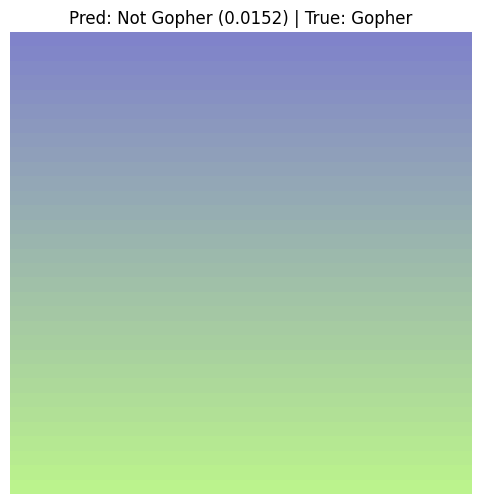

In [ ]:
import matplotlib.pyplot as plt

train_acc = (predict(forward_pass(X_flat, w, b)) == y_train).mean()
test_acc = (predict(forward_pass(X_test, w, b)) == y_test).mean()
print(f"train acc: {train_acc:.3f}   test acc: {test_acc:.3f}")

test_image = X_test[100].reshape(1, -1)
prediction_prob = forward_pass(test_image, w, b)
prediction = predict(prediction_prob)

img_display = (X_test[100].reshape(32, 32, 3) * 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(img_display)
plt.title(f"Pred: {'Gopher' if prediction[0][0] == 1 else 'Not Gopher'} ({prediction_prob[0][0]:.4f}) | True: {'Gopher' if y_test[0][0] == 1 else 'Not Gopher'}")
plt.axis('off')
plt.show()


train acc: 0.978   test acc: 0.955


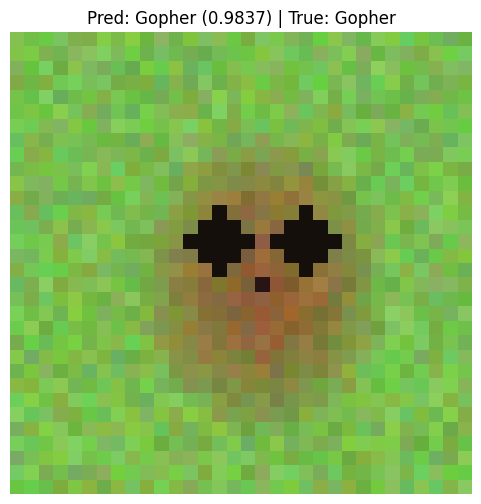

In [81]:
import matplotlib.pyplot as plt

train_acc = (predict(forward_pass(X_flat, w, b)) == y_train).mean()
test_acc = (predict(forward_pass(X_test, w, b)) == y_test).mean()
print(f"train acc: {train_acc:.3f}   test acc: {test_acc:.3f}")

test_image = X_test[0].reshape(1, -1)
prediction_prob = forward_pass(test_image, w, b)
prediction = predict(prediction_prob)

img_display = (X_test[0].reshape(32, 32, 3) * 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(img_display)
plt.title(f"Pred: {'Gopher' if prediction[0][0] == 1 else 'Not Gopher'} ({prediction_prob[0][0]:.4f}) | True: {'Gopher' if y_test[0][0] == 1 else 'Not Gopher'}")
plt.axis('off')
plt.show()


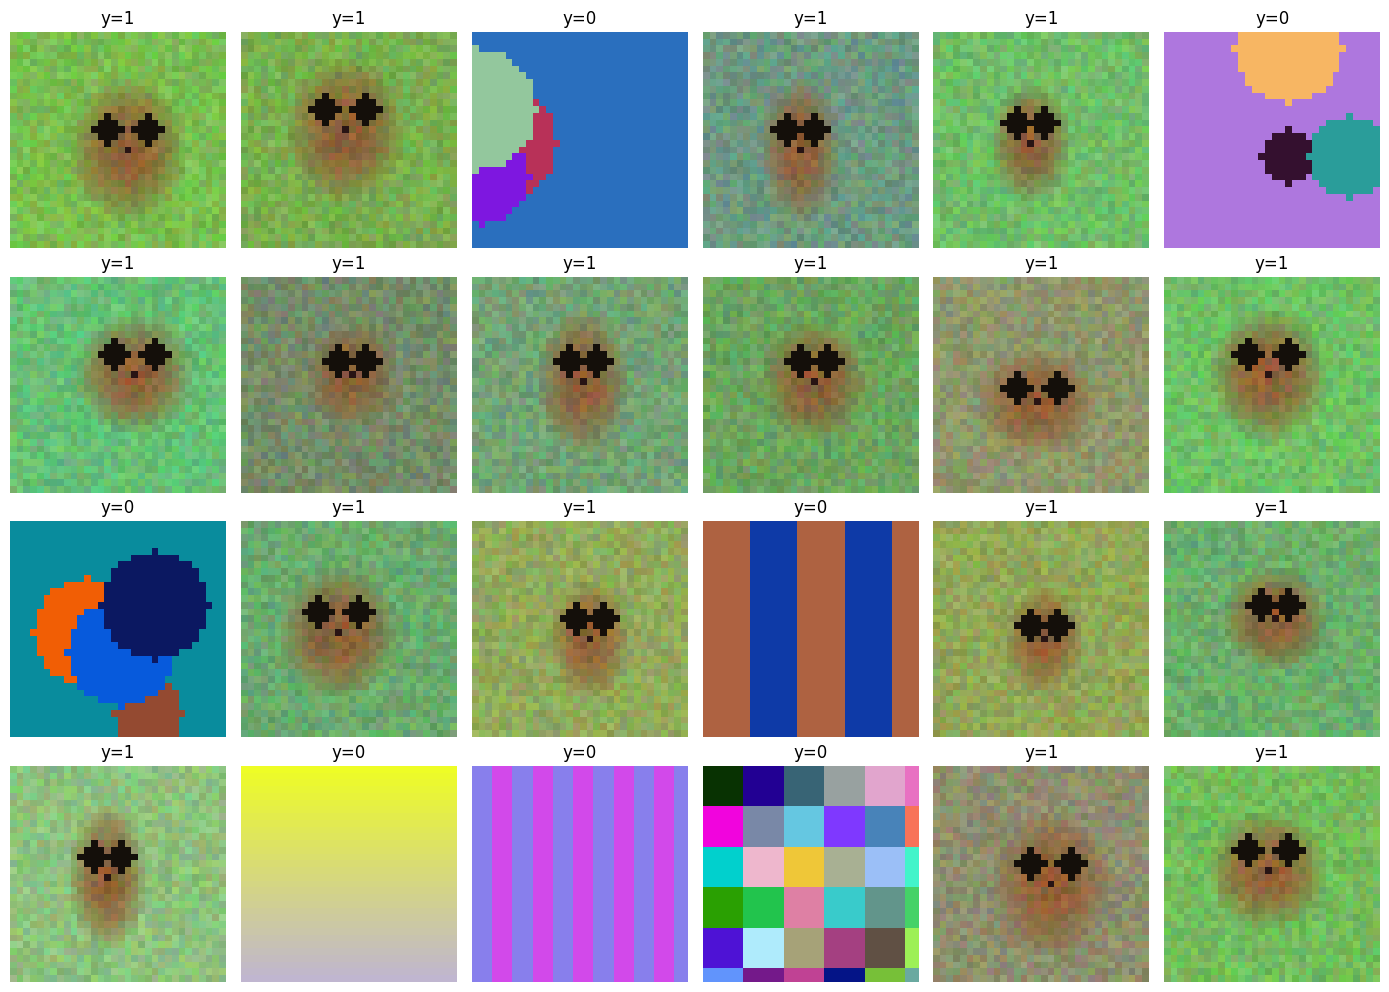

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# show a grid of test images with true labels
fig, axes = plt.subplots(4, 6, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    img = (X_test[i].reshape(32, 32, 3) * 255).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(f"y={int(y_test[i][0])}")
    ax.axis('off')
plt.tight_layout()
plt.show()


shapes: (1600, 32, 32, 3) (1600,) (400, 32, 32, 3) (400,)


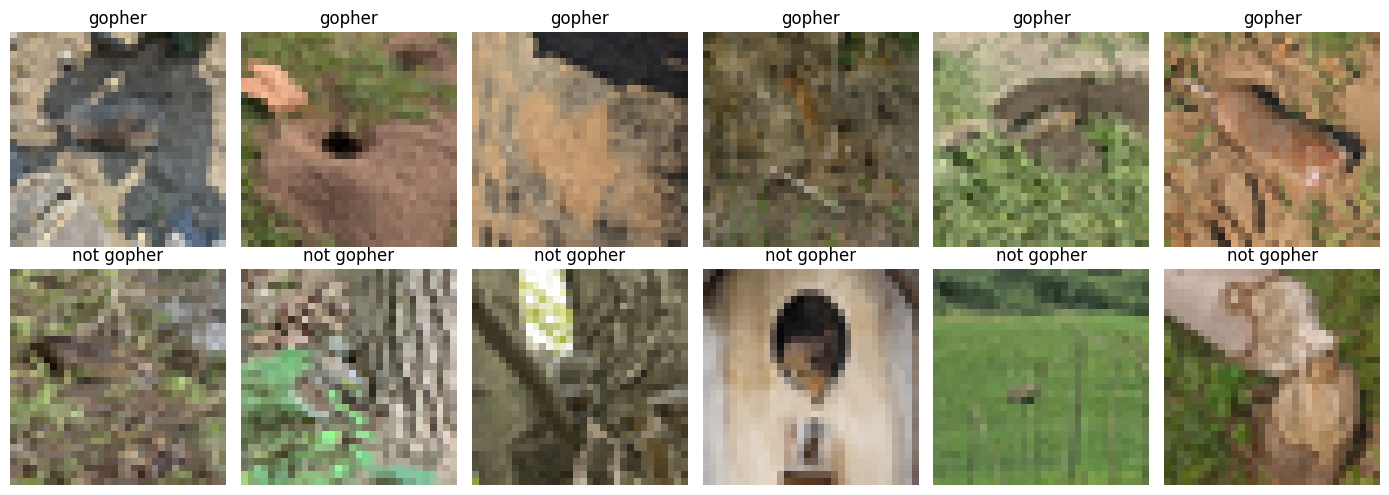

In [83]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("data/gopher_dataset.npz")
Xtr_raw, ytr_raw = d["X_train"], d["y_train"]
Xte_raw, yte_raw = d["X_test"], d["y_test"]
print("shapes:", Xtr_raw.shape, ytr_raw.shape, Xte_raw.shape, yte_raw.shape)

# show 6 gophers, 6 non-gophers
gophers = Xtr_raw[ytr_raw == 1][:6]
nongophers = Xtr_raw[ytr_raw == 0][:6]

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    axes[0, i].imshow(gophers[i]); axes[0, i].axis("off"); axes[0, i].set_title("gopher")
    axes[1, i].imshow(nongophers[i]); axes[1, i].axis("off"); axes[1, i].set_title("not gopher")
plt.tight_layout(); plt.show()
